<a href="https://colab.research.google.com/github/gurram-rohith/MDS-LAB/blob/main/07_08_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

100%|██████████| 18.5k/18.5k [00:00<00:00, 21.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tawfikelmetwally/employee-dataset/versions/1


In [2]:
import os
import pandas as pd

# List the contents of the downloaded directory
print("Files in the dataset directory:")
for file in os.listdir(path):
    print(file)

Files in the dataset directory:
Employee.csv


Based on the file list, I'll assume `Employee.csv` is the main dataset file. Let's load it into a pandas DataFrame and display the first few rows.

In [5]:
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Employee.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
# display(df.head())
display(df)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [7]:
display(df.head(10))

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


In [9]:
display(df.tail())

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0
4652,Bachelors,2015,Bangalore,3,33,Male,Yes,4,0


In [11]:
bachelors_employees_df = df[df["Education"]=="Bachelors"]
display(bachelors_employees_df)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
...,...,...,...,...,...,...,...,...,...
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [12]:
male_df=df[df["Gender"]=="Male"]
display(male_df)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
...,...,...,...,...,...,...,...,...,...
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [14]:
numerical_cols = ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']

print("--- Mean ---")
display(df[numerical_cols].mean())

print("\n--- Median ---")
display(df[numerical_cols].median())

print("\n--- Mode (first mode if multiple exist) ---")
# Mode can return multiple values if there's a tie, so we take the first one.
display(df[numerical_cols].mode().iloc[0])

--- Mean ---


,0
JoiningYear,2015.062970
PaymentTier,2.698259
Age,29.393295
ExperienceInCurrentDomain,2.905652



--- Median ---


,0
JoiningYear,2015.0
PaymentTier,3.0
Age,28.0
ExperienceInCurrentDomain,3.0



--- Mode (first mode if multiple exist) ---


,0
JoiningYear,2017
PaymentTier,3
Age,26
ExperienceInCurrentDomain,2


In [16]:
categorical_cols = ['Education', 'City', 'Gender', 'EverBenched', 'LeaveOrNot']

for col in categorical_cols:
    print(f"\n--- Value Counts for {col} ---")
    display(df[col].value_counts())


--- Value Counts for Education ---


,count
Education,
Bachelors,3601
Masters,873
PHD,179



--- Value Counts for City ---


,count
City,
Bangalore,2228
Pune,1268
New Delhi,1157



--- Value Counts for Gender ---


,count
Gender,
Male,2778
Female,1875



--- Value Counts for EverBenched ---


,count
EverBenched,
No,4175
Yes,478



--- Value Counts for LeaveOrNot ---


,count
LeaveOrNot,
0,3053
1,1600


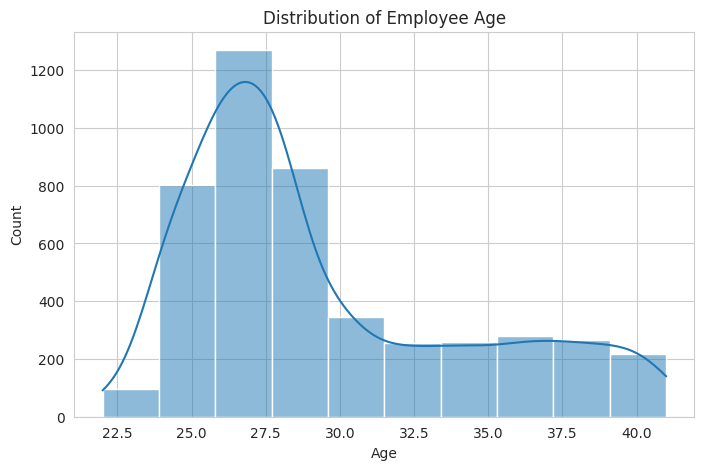

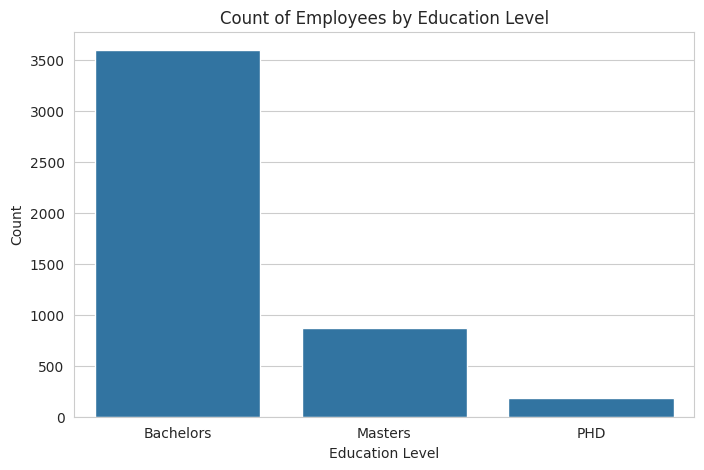

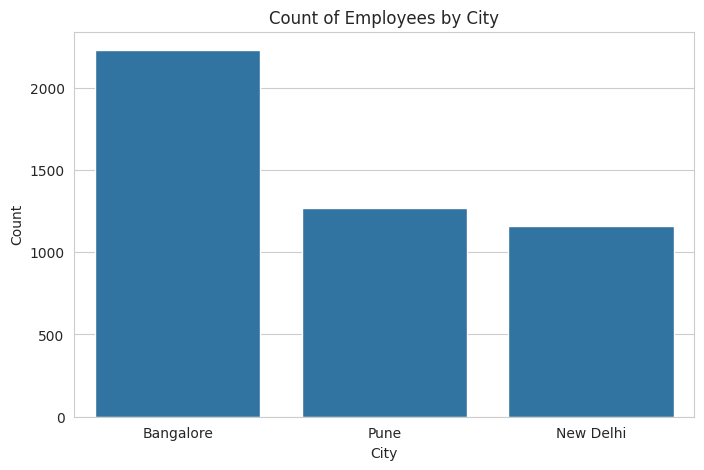

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Plot the distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Employee Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Plot the distribution of Education
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index)
plt.title('Count of Employees by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

# Plot the distribution of City
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='City', order=df['City'].value_counts().index)
plt.title('Count of Employees by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()